In [1]:
import pandas as pd
import sqlite3
import os
import matplotlib.pyplot as plt

# 현재 작업 경로 확인
print("현재 작업 폴더:", os.getcwd())

# DB 연결
conn = sqlite3.connect("../db/olist.db")

# 상품 카테고리 기본 확인
print(pd.read_sql("""
SELECT
    COUNT(*) AS total_products,
    COUNT(DISTINCT product_category_name) AS distinct_categories,
    SUM(CASE WHEN product_category_name IS NULL THEN 1 ELSE 0 END) AS null_category_products
FROM products;
""", conn))

현재 작업 폴더: /Users/chaeyoung/Documents/GitHub/olist-ecommerce-analysis/notebooks
   total_products  distinct_categories  null_category_products
0           32951                   73                     610


In [2]:
# delivered 주문 기준 카테고리별 판매 성과 분석
category_summary = pd.read_sql("""
WITH category_sales AS (
    SELECT
        COALESCE(t.product_category_name_english, p.product_category_name, 'unknown') AS category_name,
        COUNT(DISTINCT oi.order_id) AS order_count,
        COUNT(*) AS item_count,
        ROUND(SUM(oi.price), 2) AS revenue,
        ROUND(AVG(oi.price), 2) AS avg_price
    FROM order_items oi
    JOIN orders o
        ON oi.order_id = o.order_id
    JOIN products p
        ON oi.product_id = p.product_id
    LEFT JOIN product_category_name_translation t
        ON p.product_category_name = t.product_category_name
    WHERE o.order_status = 'delivered'
    GROUP BY category_name
)
SELECT *
FROM category_sales
ORDER BY revenue DESC
LIMIT 15;
""", conn)

print(category_summary)

            category_name  order_count  item_count     revenue  avg_price
0           health_beauty         8647        9465  1233131.72     130.28
1           watches_gifts         5495        5859  1166176.98     199.04
2          bed_bath_table         9272       10953  1023434.76      93.44
3          sports_leisure         7530        8431   954852.55     113.25
4   computers_accessories         6530        7644   888724.61     116.26
5         furniture_decor         6307        8160   711927.69      87.25
6              housewares         5743        6795   615628.69      90.60
7              cool_stuff         3559        3718   610204.10     164.12
8                    auto         3810        4140   578966.65     139.85
9                    toys         3804        4030   471286.48     116.94
10           garden_tools         3448        4268   470495.28     110.24
11                   baby         2809        2982   400421.84     134.28
12              perfumery         3086

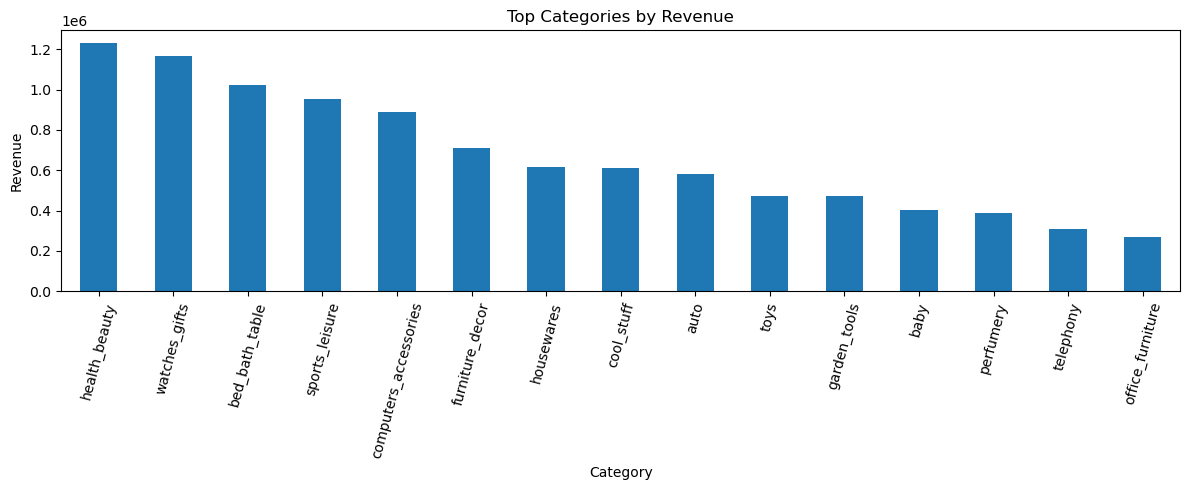

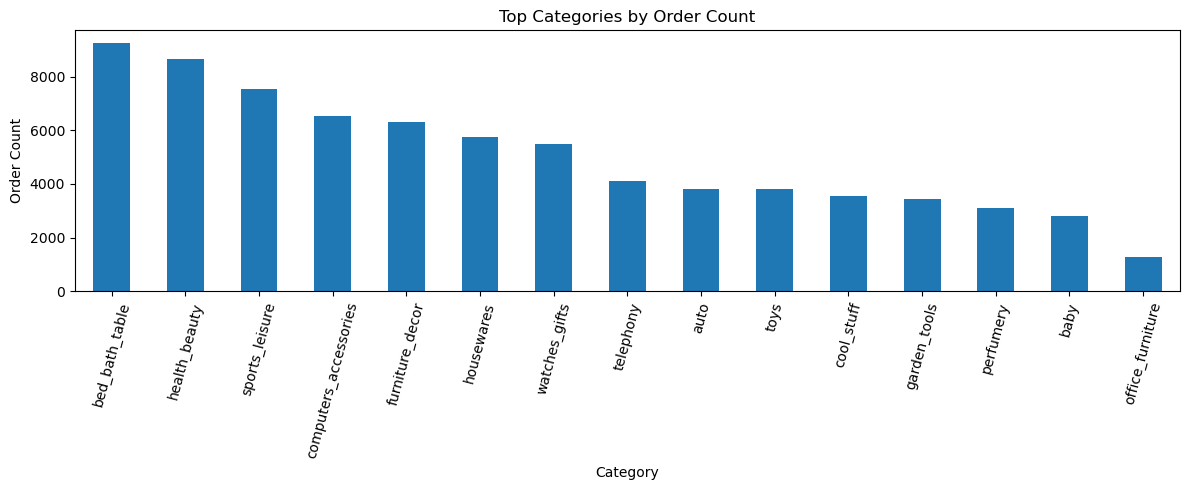

In [3]:
# 매출 상위 카테고리 시각화
category_summary.plot(
    kind="bar",
    x="category_name",
    y="revenue",
    figsize=(12, 5),
    legend=False
)

plt.title("Top Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

# 주문 수 상위 카테고리 시각화
category_summary.sort_values("order_count", ascending=False).plot(
    kind="bar",
    x="category_name",
    y="order_count",
    figsize=(12, 5),
    legend=False
)

plt.title("Top Categories by Order Count")
plt.xlabel("Category")
plt.ylabel("Order Count")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [4]:
# 카테고리별 매출 비중 확인
category_share = pd.read_sql("""
WITH category_sales AS (
    SELECT
        COALESCE(t.product_category_name_english, p.product_category_name, 'unknown') AS category_name,
        ROUND(SUM(oi.price), 2) AS revenue
    FROM order_items oi
    JOIN orders o
        ON oi.order_id = o.order_id
    JOIN products p
        ON oi.product_id = p.product_id
    LEFT JOIN product_category_name_translation t
        ON p.product_category_name = t.product_category_name
    WHERE o.order_status = 'delivered'
    GROUP BY category_name
),
total_revenue AS (
    SELECT SUM(revenue) AS total_revenue
    FROM category_sales
)
SELECT
    category_name,
    revenue,
    ROUND(revenue * 100.0 / (SELECT total_revenue FROM total_revenue), 2) AS revenue_pct
FROM category_sales
ORDER BY revenue DESC
LIMIT 15;
""", conn)

print(category_share)

            category_name     revenue  revenue_pct
0           health_beauty  1233131.72         9.33
1           watches_gifts  1166176.98         8.82
2          bed_bath_table  1023434.76         7.74
3          sports_leisure   954852.55         7.22
4   computers_accessories   888724.61         6.72
5         furniture_decor   711927.69         5.38
6              housewares   615628.69         4.66
7              cool_stuff   610204.10         4.62
8                    auto   578966.65         4.38
9                    toys   471286.48         3.56
10           garden_tools   470495.28         3.56
11                   baby   400421.84         3.03
12              perfumery   390144.65         2.95
13              telephony   309860.23         2.34
14       office_furniture   268154.31         2.03
